# Step 1 -  Load and EDA
- here we load the data and perfrom EDA
- for checking the null values and dtypes 

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data.csv')
df.head()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US


In [3]:
df.info()    # We can check Dtype and Null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793351 entries, 0 to 793350
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   invoice_id        793351 non-null  object 
 1   customer_id       793351 non-null  object 
 2   transaction_date  793351 non-null  object 
 3   product_id        793351 non-null  object 
 4   quantity          793351 non-null  int64  
 5   unit_price        793351 non-null  int64  
 6   total             793351 non-null  int64  
 7   discount_rate     793351 non-null  float64
 8   refund_flag       793351 non-null  int64  
 9   payment_method    793351 non-null  object 
 10  country           793351 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 66.6+ MB


In [4]:
df.isnull().sum()      # To chechk null values

invoice_id          0
customer_id         0
transaction_date    0
product_id          0
quantity            0
unit_price          0
total               0
discount_rate       0
refund_flag         0
payment_method      0
country             0
dtype: int64

In [5]:
df.nunique()      # Helps to understand how many customer's  data here and same for another columns 

invoice_id          793351
customer_id          19970
transaction_date       720
product_id             100
quantity                 5
unit_price           20759
total                70391
discount_rate           41
refund_flag              2
payment_method           5
country                 10
dtype: int64

In [6]:
df.describe()   # For STD, count, mean.....

,quantity,unit_price,total,discount_rate,refund_flag
count,793351.000000,793351.000000,793351.000000,793351.000000,793351.000000
mean,3.001179,6321.968230,18964.420942,0.200107,0.055127
std,1.414622,5367.747432,19925.866928,0.115571,0.228228
min,1.000000,5.000000,5.000000,0.000000,0.000000
25%,2.000000,1879.000000,4053.000000,0.100000,0.000000
50%,3.000000,5162.000000,12487.000000,0.200000,0.000000
75%,4.000000,9683.000000,27613.000000,0.300000,0.000000
max,5.000000,21000.000000,105000.000000,0.400000,1.000000


In [7]:
# We can see that here date is in string so we have to convert it

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Step 2 - Clean the transaction

In [8]:
df.duplicated()    # here we have no duplicates

0         False
1         False
2         False
3         False
4         False
          ...  
793346    False
793347    False
793348    False
793349    False
793350    False
Length: 793351, dtype: bool

In [9]:
df.drop_duplicates()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US
...,...,...,...,...,...,...,...,...,...,...,...
793346,INV0347654,C08778,2024-12-20,P008,4,1399,5594,0.15,0,Card,UK
793347,INV0636071,C15947,2024-12-20,P091,5,13561,67804,0.05,0,PayPal,UK
793348,INV0135655,C03465,2024-12-20,P025,2,12339,24677,0.04,0,PayPal,UK
793349,INV0289587,C07292,2024-12-20,P001,4,11326,45305,0.11,0,Card,US


In [10]:
# here we have to create a revenue column which is IMP 

df['revenue'] = df['total'] * (1 - df['discount_rate'])

In [11]:
df = df[df['refund_flag'] == 0]         # So it removes the data who refunded so we don't have revenue of them

In [12]:
df.head()

,invoice_id,customer_id,transaction_date,product_id,quantity,unit_price,total,discount_rate,refund_flag,payment_method,country,revenue
0,INV0079407,C02045,2023-01-01,P048,2,8584,17168,0.14,0,Card,Germany,14764.48
1,INV0581190,C14584,2023-01-01,P090,4,7779,31118,0.16,0,Card,UK,26139.12
2,INV0410888,C10301,2023-01-01,P043,5,6183,30913,0.32,0,Card,US,21020.84
3,INV0429115,C10733,2023-01-01,P085,5,14,68,0.39,0,Card,India,41.48
4,INV0020948,C00558,2023-01-01,P006,5,15309,76547,0.24,0,UPI,US,58175.72


# Step 3 - Visualization & Chart's

#### Daily Revenue

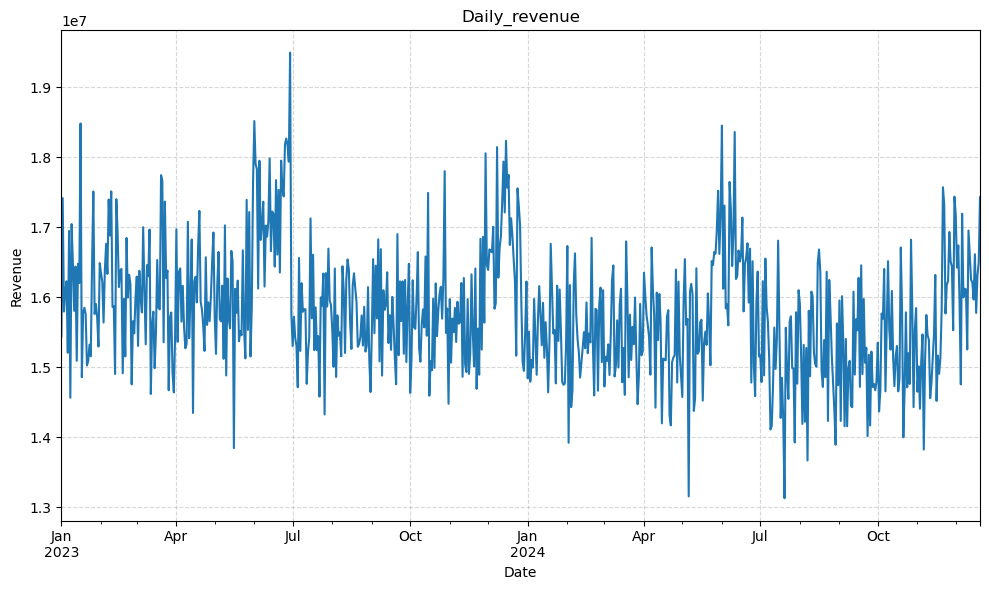

In [13]:
# Here we analyze the daily revenue trend

daily_revenue = df.resample('D', on='transaction_date')['revenue'].sum()
import matplotlib.pyplot as plt

daily_revenue.plot(figsize=(10,6))
plt.title("Daily_revenue")
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.tight_layout()

- Daily revenue remains relatively stable between 14M–17M with occasional spikes and drops, indicating consistent business activity with periodic promotional or seasonal effects.

In [14]:
df['month'] = df['transaction_date'].dt.to_period('M')

#### Monthly_revenue

C:\Users\Farhan Diwan\AppData\Local\Temp\ipykernel_22972\2520900935.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='transaction_date')['revenue'].sum()


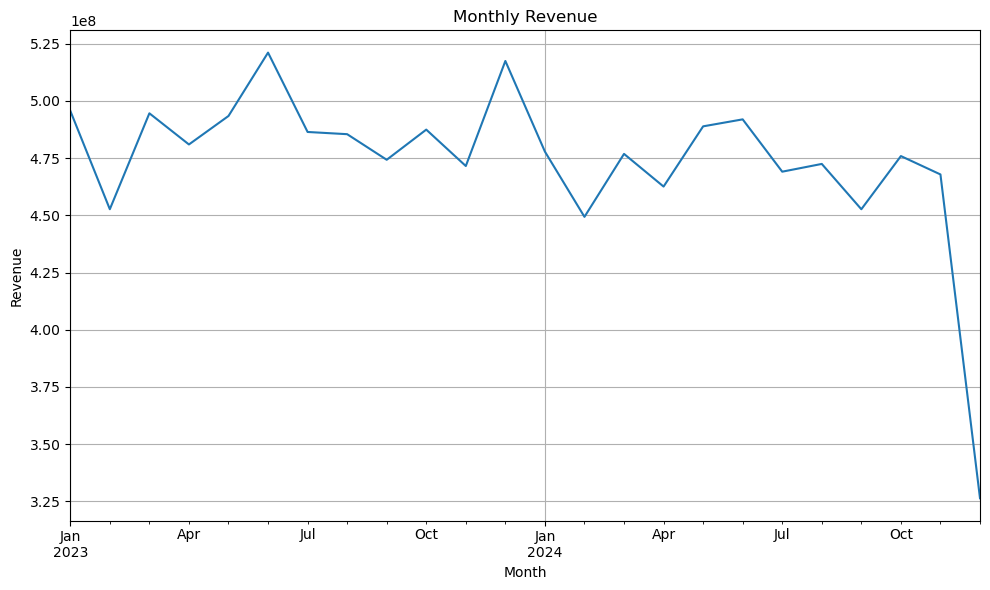

In [15]:
monthly_revenue = df.resample('M', on='transaction_date')['revenue'].sum()

monthly_revenue.plot(figsize=(10,6))
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()

- From this we can see that monthly revenue remains stable between 4.50 to 5 so we can see this much revenue we genrate per month
- And we can assume Peaks are seasonal and lows are non-seasonal month's

#### Top-Customer's

In [16]:
top_customers = df.groupby('customer_id')['revenue'].sum().nlargest(20)    # nlargest is FUNC. which gives mlargest 20 value

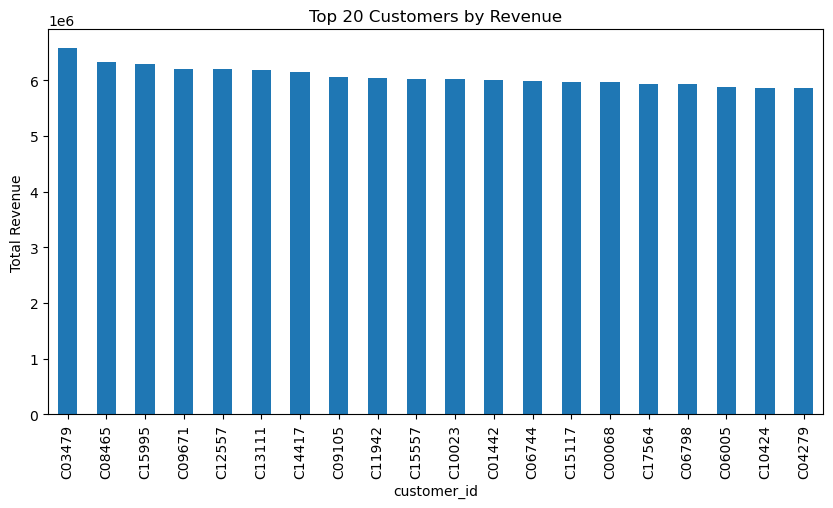

In [17]:
top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Customers by Revenue")
plt.ylabel("Total Revenue")
plt.show()

- From top customer's we can see that this cutomer's are mostly buyed from our Company

#### dicount_rate Distribution
- About 25K transactions in the dataset used a ~40% discount

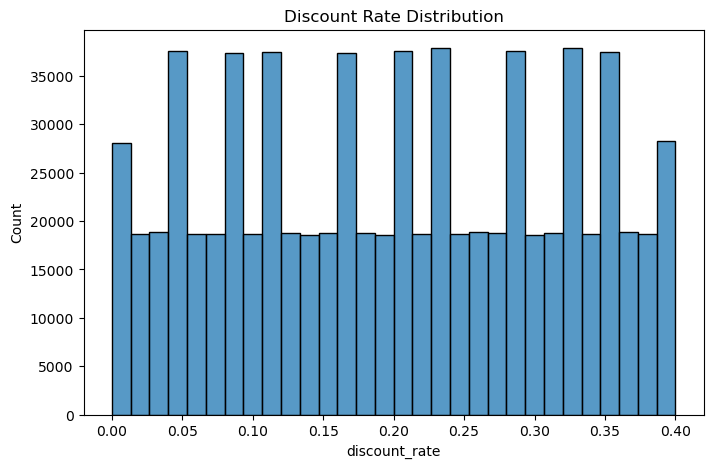

In [18]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['discount_rate'], bins=30)
plt.title("Discount Rate Distribution")
plt.show()

#### Here we can see the revenue by the payment method
- Same for the Country

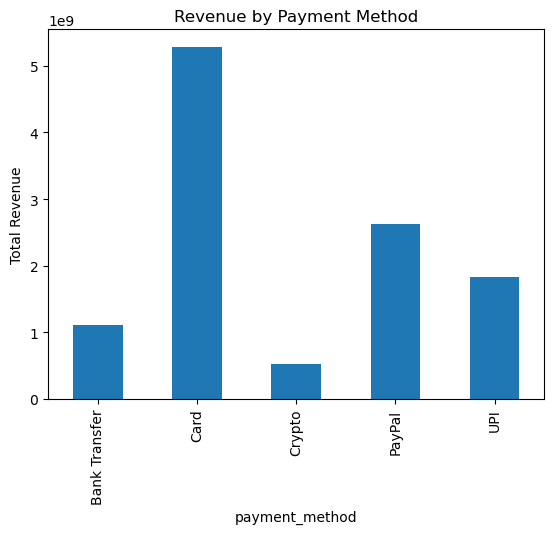

In [19]:
payment_rev = df.groupby('payment_method')['revenue'].sum()

payment_rev.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.ylabel("Total Revenue")
plt.show()

#### Revenue by country

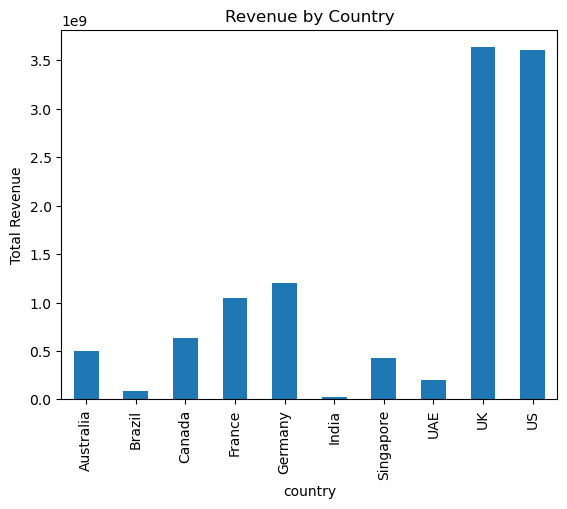

In [20]:
country_rev = df.groupby('country')['revenue'].sum()

country_rev.plot(kind='bar')
plt.title("Revenue by Country")
plt.ylabel("Total Revenue")
plt.show()

In [21]:
# Top Customer's total revenue

top_customers.max()

6584314.65

In [22]:
# Find the customer who gives us largest revenue

total_rev = df.groupby('customer_id')['revenue'].sum()
total_rev.sort_values(ascending=False)
total_rev.head(1)

customer_id
C00001    29466.26
Name: revenue, dtype: float64

In [23]:
# Most_Common discount_rate

dis = df['discount_rate'].mode()[0]      # Mode return most frequently item counts 
dis

np.float64(0.33)

In [24]:
# Top country name by revenue

top_country = country_rev.idxmax()
top_country

'UK'

# Step 4 - Define snapshot/cutoff; split past vs future

In [25]:
# First we have to short the data based on date so all months come in line

df = df.sort_values('transaction_date')

In [26]:
# Here we take 9 month for TRAINING and 3 month for TESTING
# For this we have to create a MAX_Date and CutOff_Date

In [27]:
# Max_Date and Cutoff_Date

max_date = df['transaction_date'].max()
cut_off = max_date - pd.DateOffset(months=3)           # DateOffset is FUNC... Shift a date by 3 calendar months

### Split Past vs Future - (Spliting the data based on TIME_SERIES_SPLIT) 
- Now we have to split the data bcz we do EDA ony on trainng Data
- Revenue column is needed in both bcz its our LABEL
- For Ex we have 12 month data so we take 9 = Train | 3 = Test

In [28]:
P_train = df[df['transaction_date'] < cut_off]       # Take all before the Cut_OFF
F_test = df[df['transaction_date'] >= cut_off]       # Take all after the Cut_Off

In [29]:
P_train['customer_id'].nunique()

19953

In [30]:
F_test['customer_id'].nunique()

15417

In [31]:
# This means around 4K customer's didn't buy in next 3 Months 

#### Till now we have transaction-level-dataset  but for our model 
#### we have to create customer-level-dataset from it

# Step 5 - RFM(calculations) | Customer-level-dataset
- we do this only on the Training dataset
- if we do this on test also its a data LEAKAGE

In [32]:
# In this we have to create customer data so we always work on GROUPBY('customer_id')

group = P_train.groupby('customer_id')    # So we create it in variable

#### We have to define the snapshot date 
- very imp to calculate RFM
- Last purchase date/

In [33]:
snap_date = P_train['transaction_date'].max()
snap_date

Timestamp('2024-09-19 00:00:00')

### Recency = means gap between today and its last purchase 
- In this we have to find the lateste purchase date from snapshot_date
- Here we always grouped the customer_id bcz we're creating customer_data

In [34]:
recency = (snap_date - group['transaction_date'].max()).dt.days

recency.isnull().sum()

np.int64(0)

### Frequency - how many time 1 customer buy's
- Higher frequency → higher probability of future purchases

In [35]:
frequency = group['invoice_id'].nunique()

frequency.isnull().sum()

np.int64(0)

### Monetary = Total revenue generated by a customer before the snapshot date
- Monetary = Sum of transaction totals

In [36]:
m_value = group['revenue'].sum()

m_value.isnull().sum()

np.int64(0)

### AOV(Average order value) 
- How much does this customer typically spend when they buy?
- AOV = Total money spent / Number of orders

In [37]:
aov = m_value / frequency

aov.isnull().sum()

np.int64(0)

### Tenure 
- How long has this customer been with us?
- Tenure = Number of days between the snapshot date and the customer's first purchase
- Tenure = Last Purchase Date − First Purchase Date
- High tenure → long-term customer
- Low tenure → new customer

In [38]:
tenure = (group['transaction_date'].max() - group['transaction_date'].min()).dt.days

tenure.isnull().sum()

np.int64(0)

### Revenue last 30 day's

In [39]:
cutoff_30 = P_train['transaction_date'].max() - pd.Timedelta(days=30)        # Timedelta is FUNC..... same as .DateOffset

rev_30 =  (P_train[P_train['transaction_date'] >= cutoff_30].groupby('customer_id')['revenue'].sum())         # TD > CUT...... we want next data from CUT

rev_30.isnull().sum()

np.int64(0)

### Revenue last 30 day's

In [40]:
cutoff_90 = P_train['transaction_date'].max() - pd.Timedelta(days=90)            # Timedelta = Day's   |    DateOffset = Month's

rev_90 = (P_train[P_train['transaction_date'] >= cutoff_90].groupby('customer_id')['revenue'].sum())

rev_90.isnull().sum()

np.int64(0)

### Order's in last 30 day's

In [41]:
order_30 = P_train[P_train['transaction_date'] >= cutoff_30].groupby('customer_id')['invoice_id'].nunique()

### Order's in last 90 day's

In [42]:
order_90 = P_train[P_train['transaction_date'] >= cutoff_90].groupby('customer_id')['invoice_id'].nunique()

### Purchase_velocity = frequency / tenure
- means how fast a customer place order 
- like F=2 and T=10  so it order's in 5 days

In [43]:
purchase_velocity = (frequency / tenure.replace(0,1)).round(4)

### Purchase Trend
- purchase_trend = revenue_last_30_days / revenue_last_90_days
- whether spending is growing or declining

In [44]:
purchase_trend = rev_30.div(rev_90.replace(0,1), fill_value=0)

In [45]:
mean_disc = (P_train.groupby("customer_id")["discount_rate"].mean())

## Create customer DataFrame

In [46]:
customer_df = pd.DataFrame({
    'recency': recency,
    'frequency': frequency,
    'monetary': m_value,
    'aov': aov,
    'tenure': tenure,
    'revenue_last_30_days': rev_30,
    'revenue_last_90_days': rev_90,
    'orders_last_30_days': order_30,
    'orders_last_90_days': order_90,
    'purchase_velocity': purchase_velocity
})

# replace missing activity with 0
customer_df = customer_df.fillna(0)

# compute trend safely
customer_df["purchase_trend"] = (
    customer_df["revenue_last_30_days"] /
    customer_df["revenue_last_90_days"].replace(0,1)
)

In [47]:
customer_df =  customer_df.reset_index()
customer_df["mean_discount"] = (
    customer_df["customer_id"].map(mean_disc).fillna(0)
)

In [48]:
customer_df

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount
0,C00001,420,3,26120.41,8706.803333,182,0.00,0.00,0.0,0.0,0.0165,0.000000,0.250000
1,C00002,20,34,122072.20,3590.358824,599,1468.94,8220.64,2.0,4.0,0.0568,0.178689,0.215294
2,C00003,59,4,9363.40,2340.850000,288,0.00,2127.20,0.0,1.0,0.0139,0.000000,0.252500
3,C00004,539,2,3139.84,1569.920000,66,0.00,0.00,0.0,0.0,0.0303,0.000000,0.375000
4,C00005,51,9,26944.34,2993.815556,446,0.00,646.40,0.0,1.0,0.0202,0.000000,0.146667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,C19996,224,5,29679.04,5935.808000,390,0.00,0.00,0.0,0.0,0.0128,0.000000,0.098000
19949,C19997,16,29,321439.98,11084.137241,604,21617.88,49593.28,2.0,4.0,0.0480,0.435903,0.205172
19950,C19998,448,4,24246.94,6061.735000,172,0.00,0.00,0.0,0.0,0.0233,0.000000,0.225000
19951,C19999,0,26,181921.67,6996.987308,615,3219.43,18060.70,1.0,4.0,0.0423,0.178256,0.198077


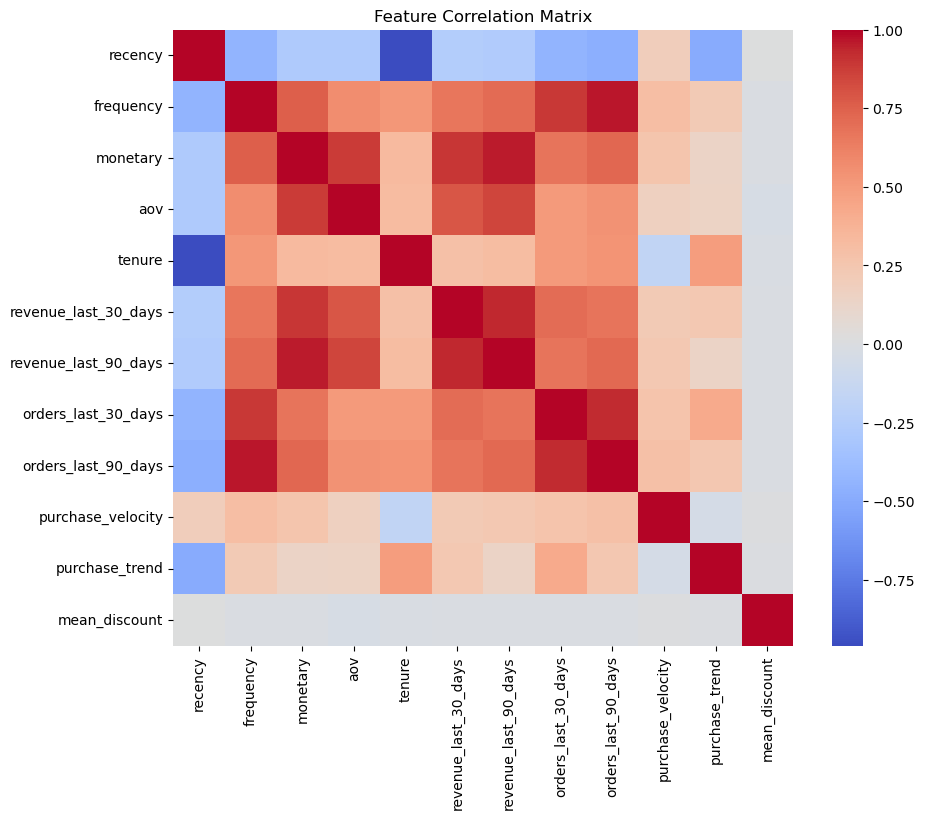

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    customer_df.corr(numeric_only=True),
    annot=False,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

# Step 6 - Create Future Revenue
- Label's of our dataset
- like if 1 customer doing this activity(fetures) in 9 month it genrate this much revenue

In [50]:
# Here we take our 3 months data for creating label

future_rev = F_test.groupby('customer_id')['revenue'].sum()

### Now we have to merge the Fetures and Labels

In [51]:
# Here we merge using the LEFT join

customer_data = customer_df.merge(future_rev, on='customer_id', how='left')

In [52]:
customer_data['revenue'] = customer_data['revenue'].fillna(0)
customer_data

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount,revenue
0,C00001,420,3,26120.41,8706.803333,182,0.00,0.00,0.0,0.0,0.0165,0.000000,0.250000,3345.85
1,C00002,20,34,122072.20,3590.358824,599,1468.94,8220.64,2.0,4.0,0.0568,0.178689,0.215294,5548.98
2,C00003,59,4,9363.40,2340.850000,288,0.00,2127.20,0.0,1.0,0.0139,0.000000,0.252500,2828.21
3,C00004,539,2,3139.84,1569.920000,66,0.00,0.00,0.0,0.0,0.0303,0.000000,0.375000,0.00
4,C00005,51,9,26944.34,2993.815556,446,0.00,646.40,0.0,1.0,0.0202,0.000000,0.146667,3144.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,C19996,224,5,29679.04,5935.808000,390,0.00,0.00,0.0,0.0,0.0128,0.000000,0.098000,6719.70
19949,C19997,16,29,321439.98,11084.137241,604,21617.88,49593.28,2.0,4.0,0.0480,0.435903,0.205172,26388.26
19950,C19998,448,4,24246.94,6061.735000,172,0.00,0.00,0.0,0.0,0.0233,0.000000,0.225000,0.00
19951,C19999,0,26,181921.67,6996.987308,615,3219.43,18060.70,1.0,4.0,0.0423,0.178256,0.198077,9740.53


- So now we have the Complate Dataset to train our model 

# Step 7 - Building Pipelines
- In this we create pipelines for scaling and encoding

In [53]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [54]:
X = customer_data.drop(['customer_id', 'revenue'], axis=1)
y = customer_data['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2,
    random_state = 42
)

In [55]:
# Defining Columns

num_col = X_train.select_dtypes(include=['number']).columns
cat_col = X_train.select_dtypes(include=['object']).columns

In [56]:
# Numerical Pipeline

num_pipeline = Pipeline([
    ('num', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

In [57]:
# Categorical Pipeline

cat_pipeline = Pipeline([
    ('cat', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [58]:
# Create ColumnTransformer

pre = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_col),
        ('cat', cat_pipeline, cat_col)
    ], verbose_feature_names_out=False
)
pre.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [59]:
# Transform the data

X_train_pre = pre.fit_transform(X_train)
X_test_pre = pre.transform(X_test)

# Step 8 - Choosing the best model 
- In this we are compare multiple model's using the cross_validation score

In [60]:
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [61]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),

    "Bagging": BaggingRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [62]:
best_model = None
best_score = -np.inf
best_model_name = None

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_pre,
        y_train,
        cv=10,
        scoring="r2"
    )

    mean_score = scores.mean()

    print(f"{name} R2 Score: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_model = model
        best_model_name = name


print("\nBest Model:", best_model_name)
print("Best CV Score:", best_score)

RandomForest R2 Score: 0.9107
XGBoost R2 Score: 0.9065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2361
[LightGBM] [Info] Number of data points in the train set: 14365, number of used features: 12
[LightGBM] [Info] Start training from score 71891.609675
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2361
[LightGBM] [Info] Number of data points in the train set: 14365, number of used features: 12
[LightGBM] [Info] Start training from score 71231.230326
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2361
[LightGBM] [Info] Number of data points in the train set:

# Step 9 - Train the best model
- Here we hypertune the best model
- Befor this we apply the log on the training data
- Log only applied on the Label's

### Applying Log to label

In [63]:
import numpy as np

y_train_log = np.log1p(y_train)

### Training the model(hyper_parameter)

In [64]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train_pre, y_train_log)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

### Make predictions
- here we also convert the predicted log value to Real Values

In [65]:
y_pred_log = cat_model.predict(X_test_pre)           # Predictions
y_pred = np.expm1(y_pred_log)         # Converting the OG values

# Step 10 - Evalute the model
- here we check accuracy and other score's

####  1. Calculate RMSE

In [66]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("CatBoost RMSE:", rmse)

CatBoost RMSE: 47110.876394588835


#### 2. Calculate R2 Score

In [67]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("CatBoost R2:", r2)

CatBoost R2: 0.901907305868131


#### 3. Calculate MAE

In [68]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 20265.741478921358


### Creating DataFrame for Pred. vs Actual
- Here we create a data frame using the prediction value and actual value

In [69]:
import pandas as pd
compare = pd.DataFrame({
    "Actual": y_test,
    "Pred": y_pred})

In [70]:
compare

,Actual,Pred
6757,48309.83,20468.368319
13198,1594.60,206.059372
15951,0.00,305.153723
16349,1067.02,450.345865
6491,7662.20,16979.188911
...,...,...
11378,6466.35,5472.995359
13936,0.00,-0.010060
9595,23212.15,13137.918236
14722,279975.82,403179.536970


In [71]:
importance = pd.Series(cat_model.feature_importances_, index=X_train_pre.columns)   # It gives how much imp the fetures are too make predictions
importance.sort_values(ascending=False)   # Gives higher value

recency                 26.298291
frequency               17.260862
monetary                13.877384
aov                      9.805711
tenure                   9.281906
purchase_velocity        7.864299
revenue_last_90_days     6.477554
mean_discount            4.530981
revenue_last_30_days     3.162660
purchase_trend           0.747309
orders_last_90_days      0.611434
orders_last_30_days      0.081610
dtype: float64

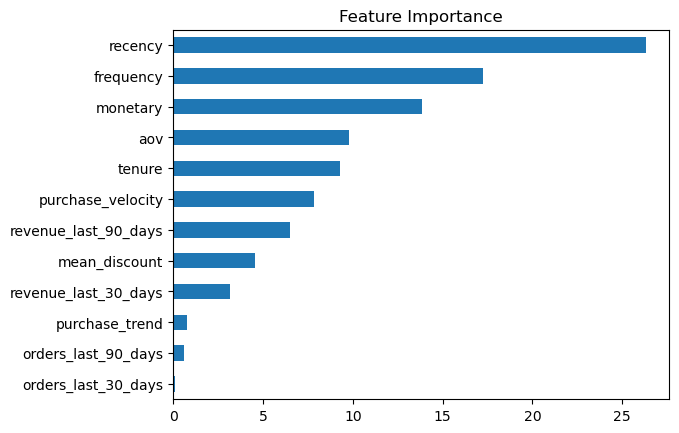

In [72]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

# Step 11 - Create customer segmentation
- In this we create a segment column based on the predicted revenue
- for that first we need to add the predicted_revenue column in customer dataset

### First we have to predict the model on our customer_df
- 9 month feture dataset

In [75]:
# Here we remove the customer_id from the 9 months data (customer_df)

new_test = customer_df.drop('customer_id', axis=1)

- If we train our model on LOG values we always get the result in LOG values
- No matter new data is logged or not so we always need to convert it back 
- np.exmp1(new_pred)

In [76]:
# Now we predict test the new_data on model and get predictions

new_pred_log = cat_model.predict(new_test)    # Make prediction
new_pred = np.expm1(new_pred_log)             # Convert into Real values

#### Now we make a new column predicted revenue and merge into CUSTOMER_DF

In [77]:
customer_df['predicted_revenue'] = new_pred   

# Now we have the CUSTOMER_DF dataset from which we have to create a segmanentation

In [78]:
customer_df

,customer_id,recency,frequency,monetary,aov,tenure,revenue_last_30_days,revenue_last_90_days,orders_last_30_days,orders_last_90_days,purchase_velocity,purchase_trend,mean_discount,predicted_revenue
0,C00001,420,3,26120.41,8706.803333,182,0.00,0.00,0.0,0.0,0.0165,0.000000,0.250000,7332.429600
1,C00002,20,34,122072.20,3590.358824,599,1468.94,8220.64,2.0,4.0,0.0568,0.178689,0.215294,8681.238461
2,C00003,59,4,9363.40,2340.850000,288,0.00,2127.20,0.0,1.0,0.0139,0.000000,0.252500,9621.375340
3,C00004,539,2,3139.84,1569.920000,66,0.00,0.00,0.0,0.0,0.0303,0.000000,0.375000,8430.081439
4,C00005,51,9,26944.34,2993.815556,446,0.00,646.40,0.0,1.0,0.0202,0.000000,0.146667,9285.567647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,C19996,224,5,29679.04,5935.808000,390,0.00,0.00,0.0,0.0,0.0128,0.000000,0.098000,7041.086558
19949,C19997,16,29,321439.98,11084.137241,604,21617.88,49593.28,2.0,4.0,0.0480,0.435903,0.205172,8633.390187
19950,C19998,448,4,24246.94,6061.735000,172,0.00,0.00,0.0,0.0,0.0233,0.000000,0.225000,7332.429600
19951,C19999,0,26,181921.67,6996.987308,615,3219.43,18060.70,1.0,4.0,0.0423,0.178256,0.198077,325910.065878


## Creating customer segmentation

- In this QCUT is FUNC.... which devide the data into equal parts
- here we give q = 4 so it devide the data into 4 parts
- 0-25% | 25-50% | 50-75% | 75-100%
- Labels = 4 parts labesl 

In [82]:
customer_df['segment'] = pd.qcut(                   # QCUT is FUNC.... which devide data into equal parts
    customer_df['predicted_revenue'],               # Based on this column
    q = 4,                                          # Into 4 part's
    labels = ["Low Value", "Medium Value", "High Value", "VIP"]         # 4 part's labels
)

In [84]:
customer_df['segment'].value_counts()

segment
High Value      5017
Low Value       4998
Medium Value    4985
VIP             4953
Name: count, dtype: int64

In [91]:
# Here we plot the bar chart to see how many customer's in each segment 

<Axes: title={'center': 'Customer Segment Distribution'}, xlabel='segment'>

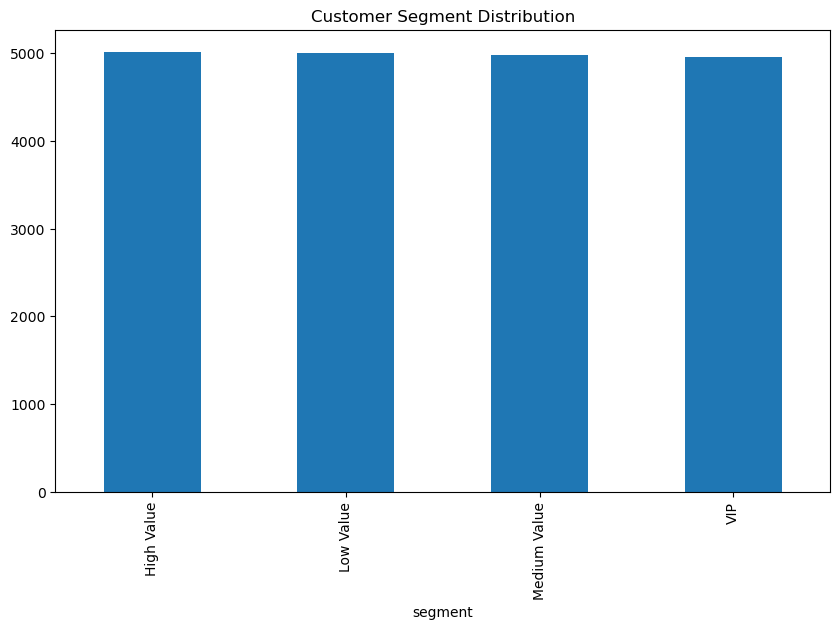

In [90]:
customer_df["segment"].value_counts().plot(kind="bar", figsize =(10,6), title="Customer Segment Distribution")

#### Now we find mininum and maximum customer's based on the Segment 

In [94]:
segment_summary = (customer_df.groupby('segment', observed=True)['predicted_revenue'].agg(['count', 'min', 'max']) )

In [95]:
segment_summary

,count,min,max
segment,,,
Low Value,4998,6950.758246,8209.839181
Medium Value,4985,8212.141012,8522.814955
High Value,5017,8523.695365,8864.934247
VIP,4953,8866.769466,456565.258354


### Creating charts 

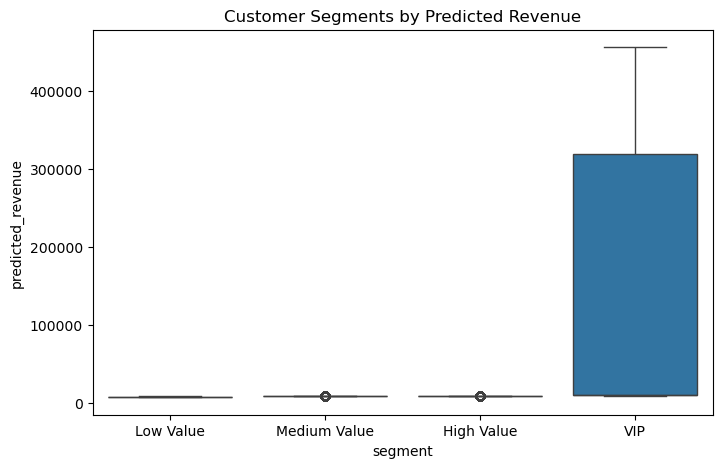

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="segment",
    y="predicted_revenue",
    data=customer_df
)

plt.title("Customer Segments by Predicted Revenue")
plt.show()

C:\Users\Farhan Diwan\AppData\Local\Temp\ipykernel_22972\3181795750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = customer_df.groupby("segment")["predicted_revenue"].sum()


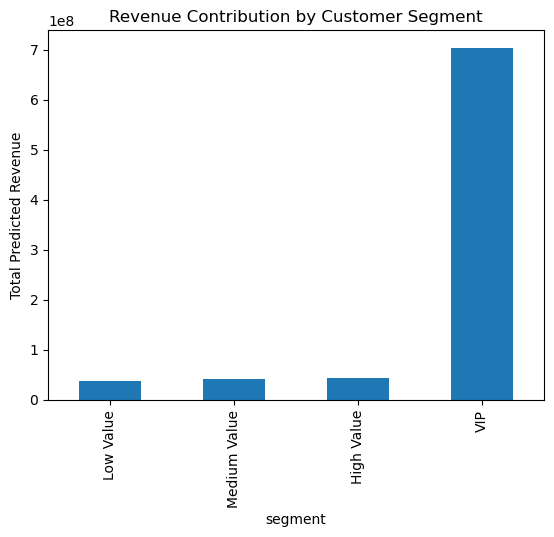

In [97]:
segment_revenue = customer_df.groupby("segment")["predicted_revenue"].sum()

segment_revenue.plot(kind="bar")
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Total Predicted Revenue")
plt.show()

- From this we can understand that the VIP customer's are going to genrate more revenue insted of other